In [4]:
!pip install lightgbm xgboost imbalanced-learn boruta fancyimpute

In [6]:
!pip list

Package                           Version
--------------------------------- ------------------
aext-assistant                    4.0.15
aext-assistant-server             4.0.15
aext-core                         4.0.15
aext-core-server                  4.0.15
aext-panels                       4.0.15
aext-panels-server                4.0.15
aext-share-notebook               4.0.15
aext-share-notebook-server        4.0.15
aext-shared                       4.0.15
aiobotocore                       2.7.0
aiohttp                           3.9.3
aioitertools                      0.7.1
aiosignal                         1.2.0
alabaster                         0.7.12
altair                            5.0.1
anaconda-anon-usage               0.4.3
anaconda-catalogs                 0.2.0
anaconda-client                   1.12.3
anaconda-cloud-auth               0.5.1
anaconda-navigator                2.6.3
anaconda-project                  0.11.1
anyio                             4.2.0
appdirs      

In [14]:
import pandas as pd
# Load dataset
df = pd.read_csv(r"C:\Users\anwesh sinha\Desktop\project\kidney_disease.csv")
# Show first 5 rows
df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [20]:
#data preprocessing
# Check for missing values in each column
df.isnull().sum()

id                  0
age                 0
bp                  0
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                 0
bu                  0
sc                  0
sod                 0
pot                 0
hemo                0
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64

In [22]:
df.dtypes


id                  int64
age               float64
bp                float64
sg                float64
al                float64
su                float64
rbc                object
pc                 object
pcc                object
ba                 object
bgr               float64
bu                float64
sc                float64
sod               float64
pot               float64
hemo              float64
pcv                object
wc                 object
rc                 object
htn                object
dm                 object
cad                object
appet              object
pe                 object
ane                object
classification     object
dtype: object

In [28]:
# Convert 'pcv', 'wc', 'rc' to numeric format because we will be imputing mean for numeric data and mode for binary data
num_fix_cols = ['pcv', 'wc', 'rc']
for col in num_fix_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')#error=coerce converts non numeric str to NaN 

In [30]:
df.dtypes

id                  int64
age               float64
bp                float64
sg                float64
al                float64
su                float64
rbc                object
pc                 object
pcc                object
ba                 object
bgr               float64
bu                float64
sc                float64
sod               float64
pot               float64
hemo              float64
pcv               float64
wc                float64
rc                float64
htn                object
dm                 object
cad                object
appet              object
pe                 object
ane                object
classification     object
dtype: object

In [34]:
# Fill missing values for numerical columns with the mean
num_cols = ['age', 'bp', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc']
for col in num_cols:
    df[col].fillna(df[col].mean(), inplace=True)#inplace=Truereplaces og instead of creating cpy

In [36]:
cat_cols = ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'classification']

# Print unique values for each categorical column
for col in cat_cols:
    print(f"{col}: {df[col].unique()}")

rbc: [nan 'normal' 'abnormal']
pc: ['normal' 'abnormal' nan]
pcc: ['notpresent' 'present' nan]
ba: ['notpresent' 'present' nan]
htn: ['yes' 'no' nan]
dm: ['yes' 'no' ' yes' '\tno' '\tyes' nan]
cad: ['no' 'yes' '\tno' nan]
appet: ['good' 'poor' nan]
pe: ['no' 'yes' nan]
ane: ['no' 'yes' nan]
classification: ['ckd' 'ckd\t' 'notckd']


In [38]:
# Strip spaces and tabs from all categorical values
cat_cols = ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'classification']

for col in cat_cols:
    df[col] = df[col].astype(str).str.strip().replace({'\tno': 'no', '\tyes': 'yes', 'ckd\t': 'ckd'})

In [40]:
for col in cat_cols:
    print(f"{col}: {df[col].unique()}")

rbc: ['nan' 'normal' 'abnormal']
pc: ['normal' 'abnormal' 'nan']
pcc: ['notpresent' 'present' 'nan']
ba: ['notpresent' 'present' 'nan']
htn: ['yes' 'no' 'nan']
dm: ['yes' 'no' 'nan']
cad: ['no' 'yes' 'nan']
appet: ['good' 'poor' 'nan']
pe: ['no' 'yes' 'nan']
ane: ['no' 'yes' 'nan']
classification: ['ckd' 'notckd']


In [42]:
from sklearn.preprocessing import LabelEncoder

binary_cols = ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'classification']

# Convert categorical labels to numeric values (Yes → 1, No → 0)
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

In [44]:
df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,1,2,1,1,...,44.0,7800.0,5.200000,2,2,1,0,1,1,0
1,1,7.0,50.0,1.020,4.0,0.0,1,2,1,1,...,38.0,6000.0,4.707435,1,1,1,0,1,1,0
2,2,62.0,80.0,1.010,2.0,3.0,2,2,1,1,...,31.0,7500.0,4.707435,1,2,1,2,1,2,0
3,3,48.0,70.0,1.005,4.0,0.0,2,0,2,1,...,32.0,6700.0,3.900000,2,1,1,2,2,2,0
4,4,51.0,80.0,1.010,2.0,0.0,2,2,1,1,...,35.0,7300.0,4.600000,1,1,1,0,1,1,0


In [46]:
binary_cols = ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']

for col in binary_cols:
    df[col] = df[col].replace({2: 1})

In [49]:
df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,1,1,1,1,...,44.0,7800.0,5.200000,1,1,1,0,1,1,0
1,1,7.0,50.0,1.020,4.0,0.0,1,1,1,1,...,38.0,6000.0,4.707435,1,1,1,0,1,1,0
2,2,62.0,80.0,1.010,2.0,3.0,1,1,1,1,...,31.0,7500.0,4.707435,1,1,1,1,1,1,0
3,3,48.0,70.0,1.005,4.0,0.0,1,0,1,1,...,32.0,6700.0,3.900000,1,1,1,1,1,1,0
4,4,51.0,80.0,1.010,2.0,0.0,1,1,1,1,...,35.0,7300.0,4.600000,1,1,1,0,1,1,0


In [53]:
#implementing MICE
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import pandas as pd

# Assuming your dataset is stored in a DataFrame called 'df'
imputer = IterativeImputer(max_iter=10, random_state=42)
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

In [84]:
#handling imbalance
from imblearn.over_sampling import BorderlineSMOTE

# Separating features and target variable
X = df_imputed.drop(columns=['classification'])
y = df_imputed['classification']

# Applying Borderline-SMOTE
smote = BorderlineSMOTE(sampling_strategy='auto', random_state=42, kind='borderline-1')
X_resampled, y_resampled = smote.fit_resample(X, y)

In [86]:
from sklearn.model_selection import train_test_split

# Define features (X) and target variable (y)
X = df.drop(columns=['classification'])  # Drop the target column
y = df['classification']  # Target variable

# Split the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check split sizes
print("Training Set Size:", X_train.shape, y_train.shape)
print("Testing Set Size:", X_test.shape, y_test.shape)

Training Set Size: (320, 25) (320,)
Testing Set Size: (80, 25) (80,)


In [62]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np

In [92]:
print(X_train.isnull().sum())

id        0
age       0
bp        0
sg       37
al       36
su       39
rbc       0
pc        0
pcc       0
ba        0
bgr       0
bu        0
sc        0
sod       0
pot       0
hemo      0
pcv       0
wc        0
rc        0
htn       0
dm        0
cad       0
appet     0
pe        0
ane       0
dtype: int64


In [94]:
# Fill missing values in 'sg', 'al', and 'su' with the mean
X_train['sg'].fillna(X_train['sg'].mean(), inplace=True)
X_train['al'].fillna(X_train['al'].mean(), inplace=True)
X_train['su'].fillna(X_train['su'].mean(), inplace=True)

# Apply the same imputation to X_test
X_test['sg'].fillna(X_train['sg'].mean(), inplace=True)
X_test['al'].fillna(X_train['al'].mean(), inplace=True)
X_test['su'].fillna(X_train['su'].mean(), inplace=True)

In [96]:
print(X_train.isnull().sum().sum())  # Should print 0
print(X_test.isnull().sum().sum())   # Should print 0

0
0


In [98]:
#gave errors due to NaN in 3 columns so the above 2 cells
# Initialize RandomForestClassifier as the estimator for RFE
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Initialize RFE with 12 selected features (as per the paper)
rfe = RFE(estimator=rf, n_features_to_select=12)

# Fit RFE on training data
X_train_selected = rfe.fit_transform(X_train, y_train)

# Apply the same feature selection to X_test
X_test_selected = rfe.transform(X_test)

# Get the names of selected features
selected_features = X.columns[rfe.support_]
print("Selected Features:", list(selected_features))

Selected Features: ['id', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'hemo', 'pcv', 'rc']


In [100]:
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier

# Initialize a Random Forest model (used internally by Boruta)
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Initialize Boruta with the RandomForest model
boruta = BorutaPy(rf, n_estimators='auto', verbose=2, random_state=42) #?

# Fit Boruta on X_train
boruta.fit(X_train.values, y_train.values)

# Get the selected feature names
selected_features = X_train.columns[boruta.support_]
print("Selected Features by Boruta:", list(selected_features))

# Apply Boruta transformation on X_train and X_test
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	25
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	25
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	25
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	25
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	25
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	25
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	25
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	13
Tentative: 	4
Rejected: 	8
Iteration: 	9 / 100
Confirmed: 	13
Tentative: 	4
Rejected: 	8
Iteration: 	10 / 100
Confirmed: 	13
Tentative: 	4
Rejected: 	8
Iteration: 	11 / 100
Confirmed: 	13
Tentative: 	4
Rejected: 	8
Iteration: 	12 / 100
Confirmed: 	13
Tentative: 	4
Rejected: 	8
Iteration: 	13 / 100
Confirmed: 	13
Tentative: 	4
Rejected: 	8
Iteration: 	14 / 100
Confirmed: 	13
Tentative: 	4
Rejected: 	8
Iteration: 	15 / 100
Confirmed: 	13
Tentative: 	4
Rejected: 	8
Iteration: 	16 / 100
Confirmed: 	15
Tentative: 	2
Rejected: 	8
I

In [102]:
print("Final Features Selected by Boruta:", list(selected_features))
print("X_train_selected shape:", X_train_selected.shape)
print("X_test_selected shape:", X_test_selected.shape)

Final Features Selected by Boruta: ['id', 'age', 'bp', 'sg', 'al', 'su', 'pc', 'bgr', 'bu', 'sc', 'sod', 'hemo', 'pcv', 'wc', 'rc', 'appet']
X_train_selected shape: (320, 16)
X_test_selected shape: (80, 16)


In [104]:
#to standardise data so a single data doesnt dominate due to high valeu Eg)bp and sg have diff range so one doesnt dominate
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Fit on training data and transform both train & test sets
X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

In [106]:
import numpy as np

# Print mean and standard deviation
print("Mean after scaling (should be ~0):", np.mean(X_train_scaled, axis=0))
print("Std after scaling (should be ~1):", np.std(X_train_scaled, axis=0))

Mean after scaling (should be ~0): [-1.02695630e-16 -1.16573418e-16  3.53883589e-16  1.16906484e-14
  1.66533454e-17  0.00000000e+00 -1.05471187e-16  8.88178420e-17
  1.72084569e-16 -2.77555756e-18  6.74460487e-16  3.26128013e-16
  2.49800181e-16 -9.99200722e-17 -2.87270208e-16  5.96744876e-17]
Std after scaling (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [108]:
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier, VotingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np


# Initialize all models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Bagging": BaggingClassifier(n_estimators=50, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=50, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "LightGBM": LGBMClassifier(n_estimators=100, random_state=42),
}

# Store results
results = {}

# Train and evaluate each model
for name, model in models.items():
    model.fit(X_train, y_train)  # Train the model
    y_pred = model.predict(X_test)  # Make predictions

    # Calculate performance metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)

    # Store results
    results[name] = [accuracy, precision, recall, f1, roc_auc]

    # Print performance
    print(f"\n{name} Results:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"AUC-ROC: {roc_auc:.4f}")


Random Forest Results:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
AUC-ROC: 1.0000

Bagging Results:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
AUC-ROC: 1.0000

AdaBoost Results:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
AUC-ROC: 1.0000

Gradient Boosting Results:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
AUC-ROC: 1.0000

XGBoost Results:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
AUC-ROC: 1.0000
[LightGBM] [Info] Number of positive: 122, number of negative: 198
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000194 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 632
[LightGBM] [Info] Number of data points in the train set: 320, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.381250 -> initscore=-0.484246
[LightGBM] [Info] Start training from score -

E:\python\Lib\site-packages\xgboost\core.py:158: UserWarning: [20:59:28] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [112]:
import pandas as pd

# Convert results dictionary to DataFrame for easy comparison
results_df = pd.DataFrame(results, index=["Accuracy", "Precision", "Recall", "F1 Score", "AUC-ROC"])
print("\nComparison of Models:\n")
print(results_df.T.sort_values(by="Accuracy", ascending=False))


Comparison of Models:

                   Accuracy  Precision  Recall  F1 Score  AUC-ROC
Random Forest           1.0        1.0     1.0       1.0      1.0
Bagging                 1.0        1.0     1.0       1.0      1.0
AdaBoost                1.0        1.0     1.0       1.0      1.0
Gradient Boosting       1.0        1.0     1.0       1.0      1.0
XGBoost                 1.0        1.0     1.0       1.0      1.0
LightGBM                1.0        1.0     1.0       1.0      1.0


In [114]:
print("Train-Test Overlap:", len(set(X_train.index) & set(X_test.index)))


Train-Test Overlap: 0


In [116]:
print("Unique values in y_train:", np.unique(y_train))
print("Unique values in y_test:", np.unique(y_test))

Unique values in y_train: [0 1]
Unique values in y_test: [0 1]


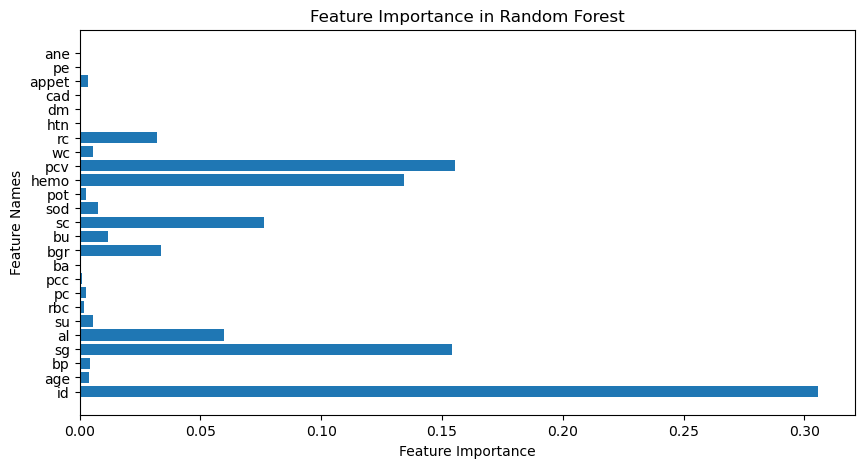

In [118]:
import matplotlib.pyplot as plt

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

importances = rf.feature_importances_
feature_names = X_train.columns

plt.figure(figsize=(10,5))
plt.barh(feature_names, importances)
plt.xlabel("Feature Importance")
plt.ylabel("Feature Names")
plt.title("Feature Importance in Random Forest")
plt.show()

In [120]:
# Remove ID from features
X_train = X_train.drop(columns=['id'])
X_test = X_test.drop(columns=['id'])

# Re-train models
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)

    results[name] = [accuracy, precision, recall, f1, roc_auc]

    print(f"\n{name} Results (Without ID):")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"AUC-ROC: {roc_auc:.4f}")


Random Forest Results (Without ID):
Accuracy: 0.9875
Precision: 0.9655
Recall: 1.0000
F1 Score: 0.9825
AUC-ROC: 0.9904

Bagging Results (Without ID):
Accuracy: 0.9875
Precision: 0.9655
Recall: 1.0000
F1 Score: 0.9825
AUC-ROC: 0.9904

AdaBoost Results (Without ID):
Accuracy: 0.9875
Precision: 0.9655
Recall: 1.0000
F1 Score: 0.9825
AUC-ROC: 0.9904

Gradient Boosting Results (Without ID):
Accuracy: 0.9875
Precision: 0.9655
Recall: 1.0000
F1 Score: 0.9825
AUC-ROC: 0.9904

XGBoost Results (Without ID):
Accuracy: 0.9875
Precision: 0.9655
Recall: 1.0000
F1 Score: 0.9825
AUC-ROC: 0.9904
[LightGBM] [Info] Number of positive: 122, number of negative: 198
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000075 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 525
[LightGBM] [Info] Number of data points in the train set: 320, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.381250 -> 

E:\python\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:07:04] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [122]:
lgbm = LGBMClassifier(n_estimators=100, random_state=42)
cv_scores = cross_val_score(lgbm, X_resampled.drop(columns=['id']), y_resampled, cv=5, scoring='accuracy')

print("Cross-Validation Scores (Without ID):", cv_scores)
print("Mean Accuracy:", np.mean(cv_scores))

[LightGBM] [Info] Number of positive: 200, number of negative: 200
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000097 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 863
[LightGBM] [Info] Number of data points in the train set: 400, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with

In [126]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Define hyperparameter grid
param_grid = {
    'n_estimators': [50, 100, 200, 500],
    'learning_rate': [0.001, 0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7, 10],
    'num_leaves': [20, 31, 40, 50],
    'min_child_samples': [5, 10, 20, 30],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

# Initialize LightGBM model
lgbm = LGBMClassifier(random_state=42)

# Set up Randomized Search
random_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_grid,
    n_iter=20,  # Number of different combinations to try
    scoring='accuracy',  # Optimize for accuracy
    cv=5,  # 5-Fold Cross-Validation
    verbose=2,
    n_jobs=-1  # Use all CPU cores
)

# Fit Randomized Search on training data
random_search.fit(X_train, y_train)

# Print best parameters
print("Best Hyperparameters:", random_search.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[LightGBM] [Info] Number of positive: 122, number of negative: 198
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000210 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 525
[LightGBM] [Info] Number of data points in the train set: 320, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.381250 -> initscore=-0.484246
[LightGBM] [Info] Start training from score -0.484246
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [

In [128]:
# Get best parameters
best_params = random_search.best_params_

# Train LightGBM with optimized parameters
best_lgbm = LGBMClassifier(**best_params, random_state=42)
best_lgbm.fit(X_train, y_train)

# Evaluate on test set
y_pred = best_lgbm.predict(X_test)

# Compute accuracy
final_accuracy = accuracy_score(y_test, y_pred)
print("Final Accuracy after Tuning:", final_accuracy)

[LightGBM] [Info] Number of positive: 122, number of negative: 198
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000092 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 525
[LightGBM] [Info] Number of data points in the train set: 320, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.381250 -> initscore=-0.484246
[LightGBM] [Info] Start training from score -0.484246
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best